# Spotify & YouTube Dataset Analysis
**Shail Desai**

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

## Load & Observe Raw Data

In [104]:
# Load data
spotify_raw = pd.read_csv("Spotify_Youtube.csv", index_col=0)
print(spotify_raw.shape)
print(spotify_raw.columns.tolist())
spotify_raw.describe()

(20718, 27)
['Artist', 'Url_spotify', 'Track', 'Album', 'Album_type', 'Uri', 'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Url_youtube', 'Title', 'Channel', 'Views', 'Likes', 'Comments', 'Description', 'Licensed', 'official_video', 'Stream']


,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,2.024800e+04,2.017700e+04,2.014900e+04,2.014200e+04
mean,0.619777,0.635250,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,9.393782e+07,6.633411e+05,2.751899e+04,1.359422e+08
std,0.165272,0.214147,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,2.746443e+08,1.789324e+06,1.932347e+05,2.441321e+08
min,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,0.518000,0.507000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.826002e+06,2.158100e+04,5.090000e+02,1.767486e+07
50%,0.637000,0.666000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,0.740250,0.798000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,7.039975e+07,5.221480e+05,1.436000e+04,1.383581e+08
max,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


## Preprocess Data

In [105]:
# Check missing values
spotify_raw.isnull().sum()

Artist                0
Url_spotify           0
Track                 0
Album                 0
Album_type            0
Uri                   0
Danceability          2
Energy                2
Key                   2
Loudness              2
Speechiness           2
Acousticness          2
Instrumentalness      2
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Url_youtube         470
Title               470
Channel             470
Views               470
Likes               541
Comments            569
Description         876
Licensed            470
official_video      470
Stream              576
dtype: int64

In [106]:
# Drop rows with missing values in key columns
spotify = spotify_raw.dropna(subset=[
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo", "Duration_ms", "Stream", "Views", "Likes"
]).copy()

print("After dropping missing:", spotify.shape)
spotify.head(5)

After dropping missing: (19624, 27)


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,-5.810,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,-8.627,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [107]:
# Convert boolean-like columns
spotify["Licensed"] = spotify["Licensed"].map({"True": True, "False": False})
spotify["official_video"] = spotify["official_video"].map({"True": True, "False": False})

print(spotify.dtypes)
spotify.describe()

Artist                  str
Url_spotify             str
Track                   str
Album                   str
Album_type              str
Uri                     str
Danceability        float64
Energy              float64
Key                 float64
Loudness            float64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Duration_ms         float64
Url_youtube             str
Title                   str
Channel                 str
Views               float64
Likes               float64
Comments            float64
Description             str
Licensed             object
official_video       object
Stream              float64
dtype: object


,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,19624.000000,19624.000000,19624.000000,19624.000000,19624.000000,19624.000000,19624.000000,19624.000000,19624.000000,19624.000000,1.962400e+04,1.962400e+04,1.962400e+04,1.954900e+04,1.962400e+04
mean,0.621003,0.634961,5.294079,-7.637436,0.095306,0.289317,0.055304,0.191204,0.528777,120.583702,2.245775e+05,9.529555e+07,6.695919e+05,2.786371e+04,1.371413e+08
std,0.165457,0.213622,3.579442,4.619568,0.106188,0.286056,0.192530,0.165209,0.245383,29.609419,1.267272e+05,2.771158e+08,1.802729e+06,1.959074e+05,2.462581e+08
min,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,2.600000e+01,0.000000e+00,0.000000e+00,6.574000e+03
25%,0.519000,0.508000,2.000000,-8.781250,0.035700,0.044400,0.000000,0.094000,0.338000,96.990750,1.801698e+05,1.907604e+06,2.232600e+04,5.310000e+02,1.781063e+07
50%,0.639000,0.666000,5.000000,-6.517500,0.050600,0.190000,0.000002,0.125000,0.535000,119.961500,2.132535e+05,1.483210e+07,1.275100e+05,3.343000e+03,4.979666e+07
75%,0.742000,0.797000,8.000000,-4.930750,0.104000,0.471000,0.000442,0.234000,0.725000,139.946000,2.518468e+05,7.147883e+07,5.269410e+05,1.449300e+04,1.392074e+08
max,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


## Explore Data

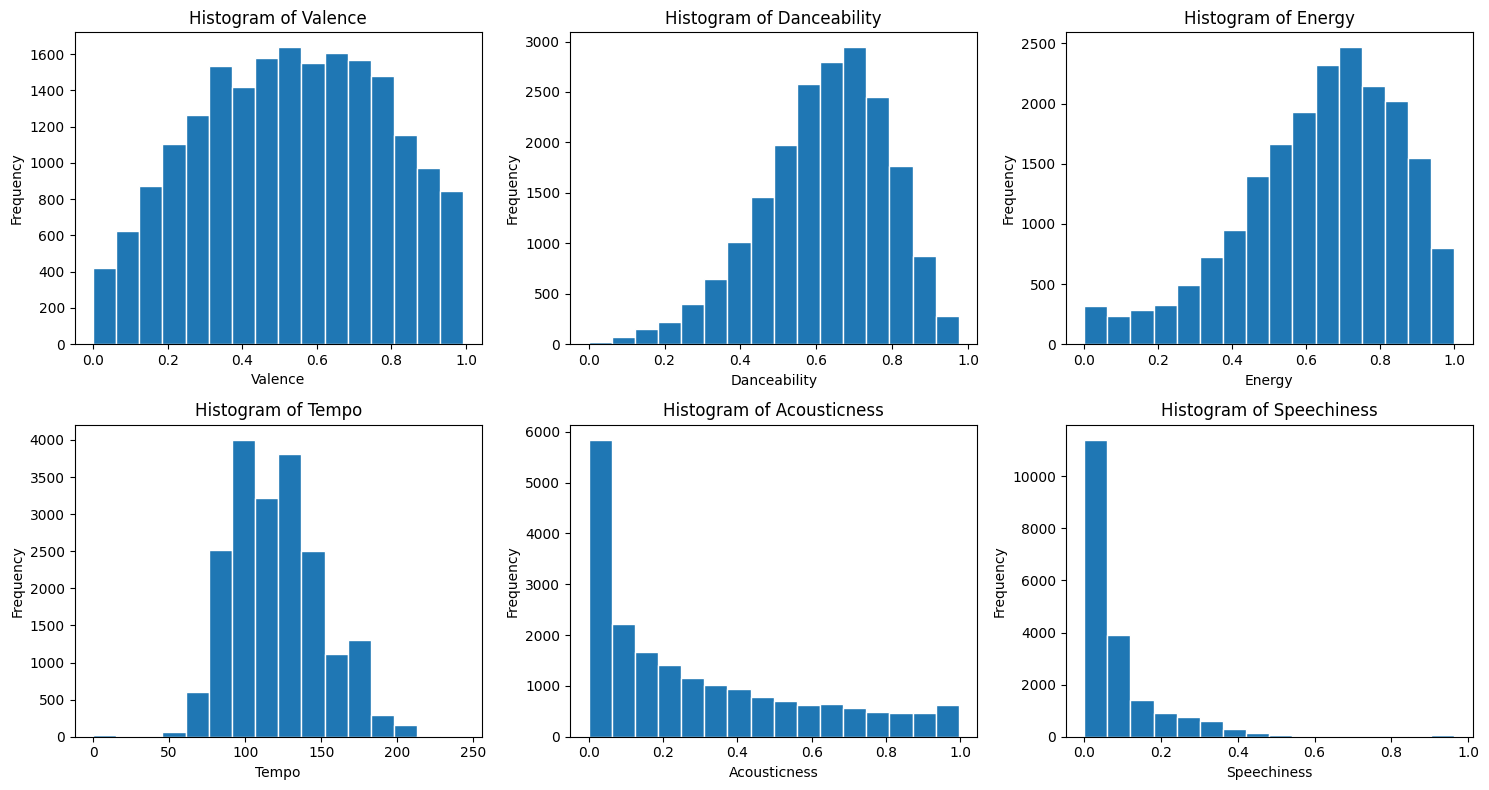

In [108]:
# Histograms of audio features
audio_features = ["Valence", "Danceability", "Energy", "Tempo", "Acousticness", "Speechiness"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, audio_features):
    ax.hist(spotify[col].dropna(), bins="sturges", edgecolor="white")
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

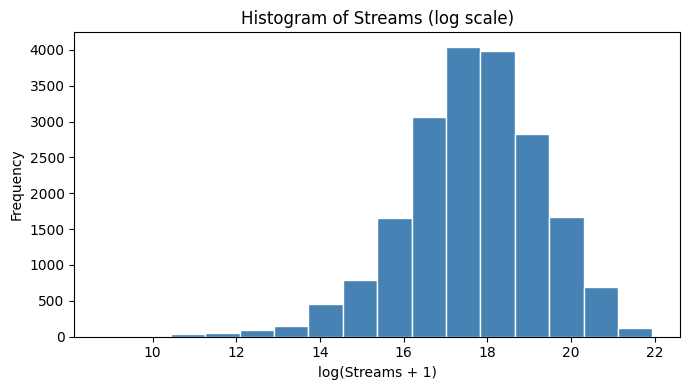

In [109]:
# Histogram of Streams (log scale)
plt.figure(figsize=(7, 4))
plt.hist(np.log1p(spotify["Stream"]), bins="sturges", edgecolor="white", color="steelblue")
plt.title("Histogram of Streams (log scale)")
plt.xlabel("log(Streams + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

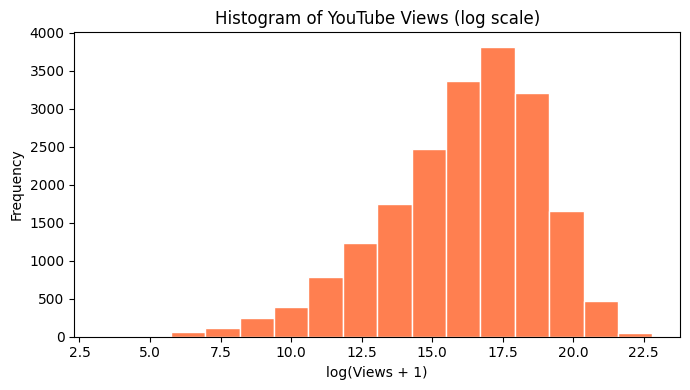

In [110]:
# Histogram of Views (log scale)
plt.figure(figsize=(7, 4))
plt.hist(np.log1p(spotify["Views"]), bins="sturges", edgecolor="white", color="coral")
plt.title("Histogram of YouTube Views (log scale)")
plt.xlabel("log(Views + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

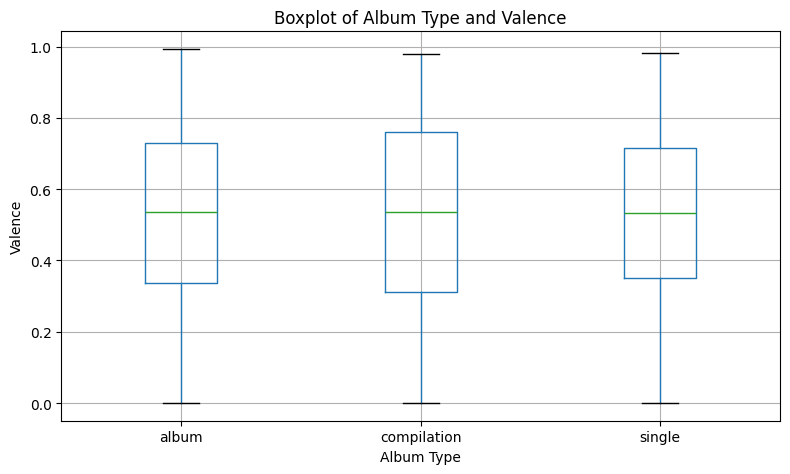

<Figure size 800x500 with 0 Axes>

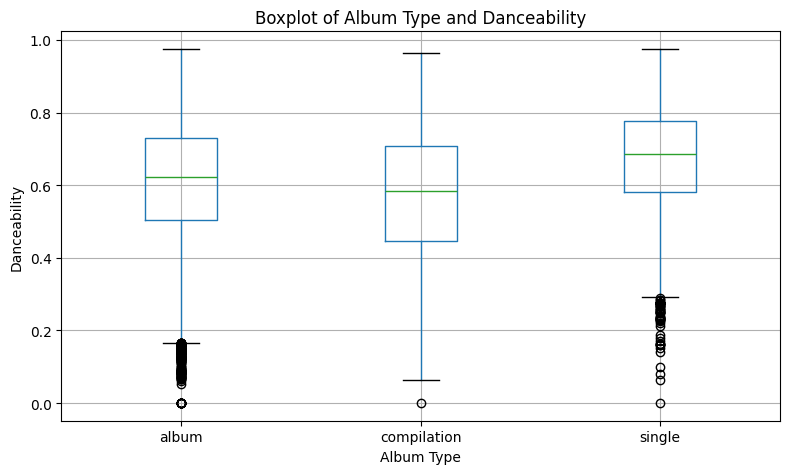

<Figure size 800x500 with 0 Axes>

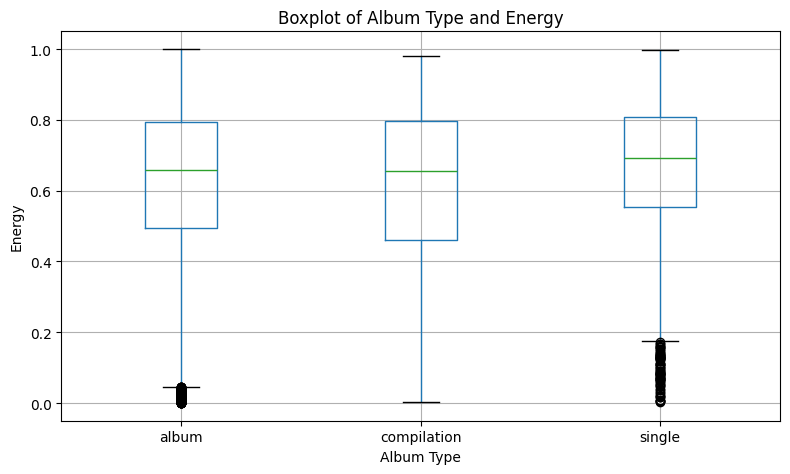

In [111]:
# Boxplots of audio features by Album type
album_types = spotify["Album_type"].dropna().unique().tolist()

for col in ["Valence", "Danceability", "Energy"]:
    plt.figure(figsize=(8, 5))
    spotify.boxplot(column=col, by="Album_type", figsize=(8, 5))
    plt.title(f"Boxplot of Album Type and {col}")
    plt.suptitle("")
    plt.xlabel("Album Type")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

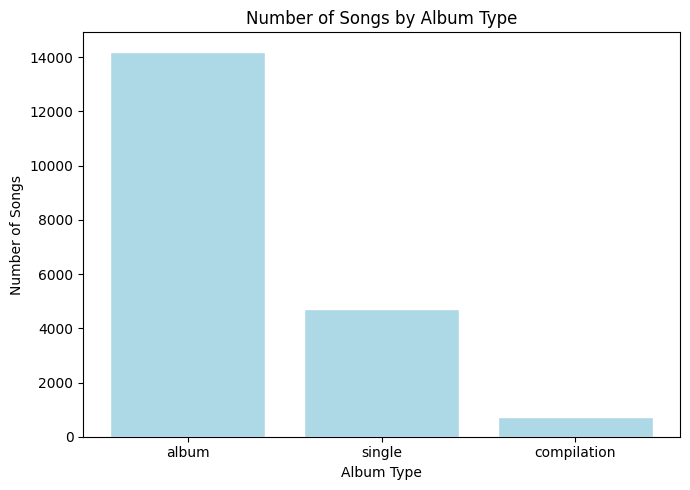

In [112]:
# Song count by Album type
album_counts = spotify["Album_type"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(album_counts.index, album_counts.values, color="lightblue", edgecolor="white")
plt.title("Number of Songs by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

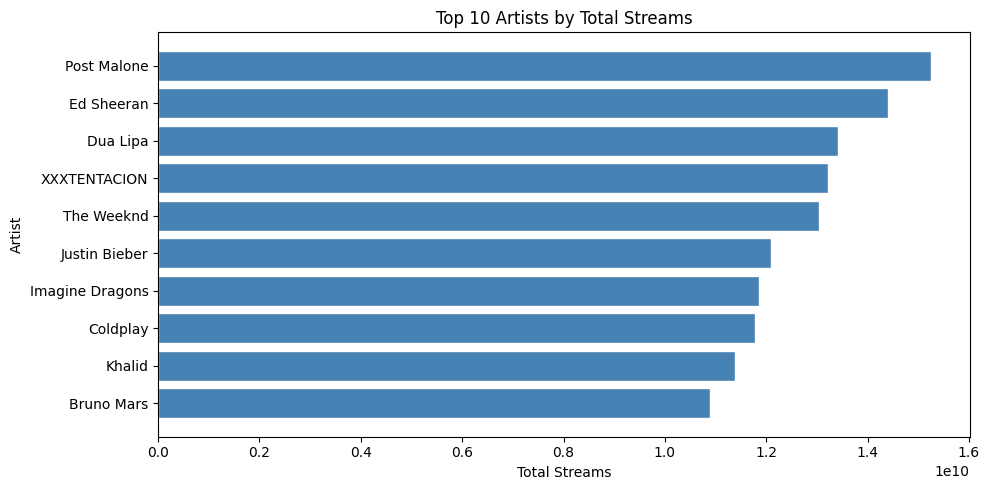

In [113]:
# Top 10 artists by total streams
top_artists = (
    spotify.groupby("Artist")["Stream"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_artists.index[::-1], top_artists.values[::-1], color="steelblue", edgecolor="white")
plt.title("Top 10 Artists by Total Streams")
plt.xlabel("Total Streams")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

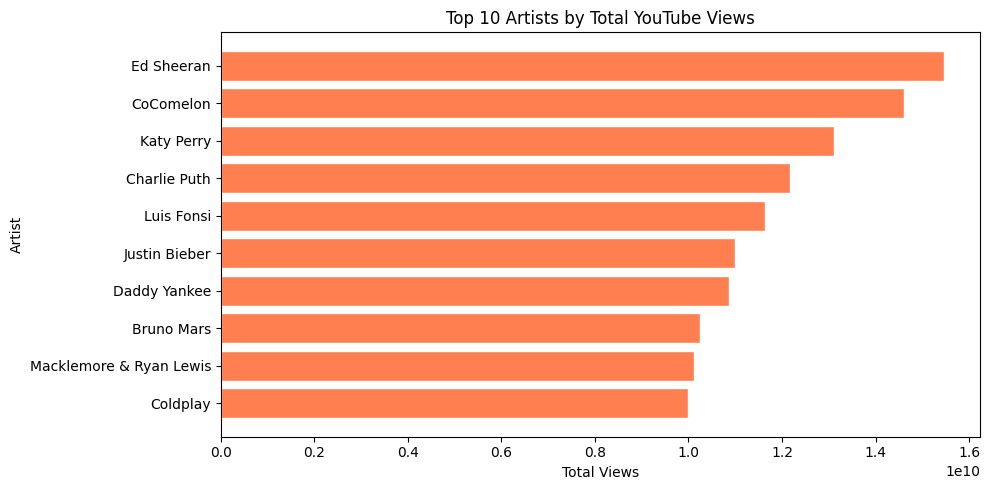

In [114]:
# Top 10 artists by total YouTube views
top_artists_views = (
    spotify.groupby("Artist")["Views"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_artists_views.index[::-1], top_artists_views.values[::-1], color="coral", edgecolor="white")
plt.title("Top 10 Artists by Total YouTube Views")
plt.xlabel("Total Views")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

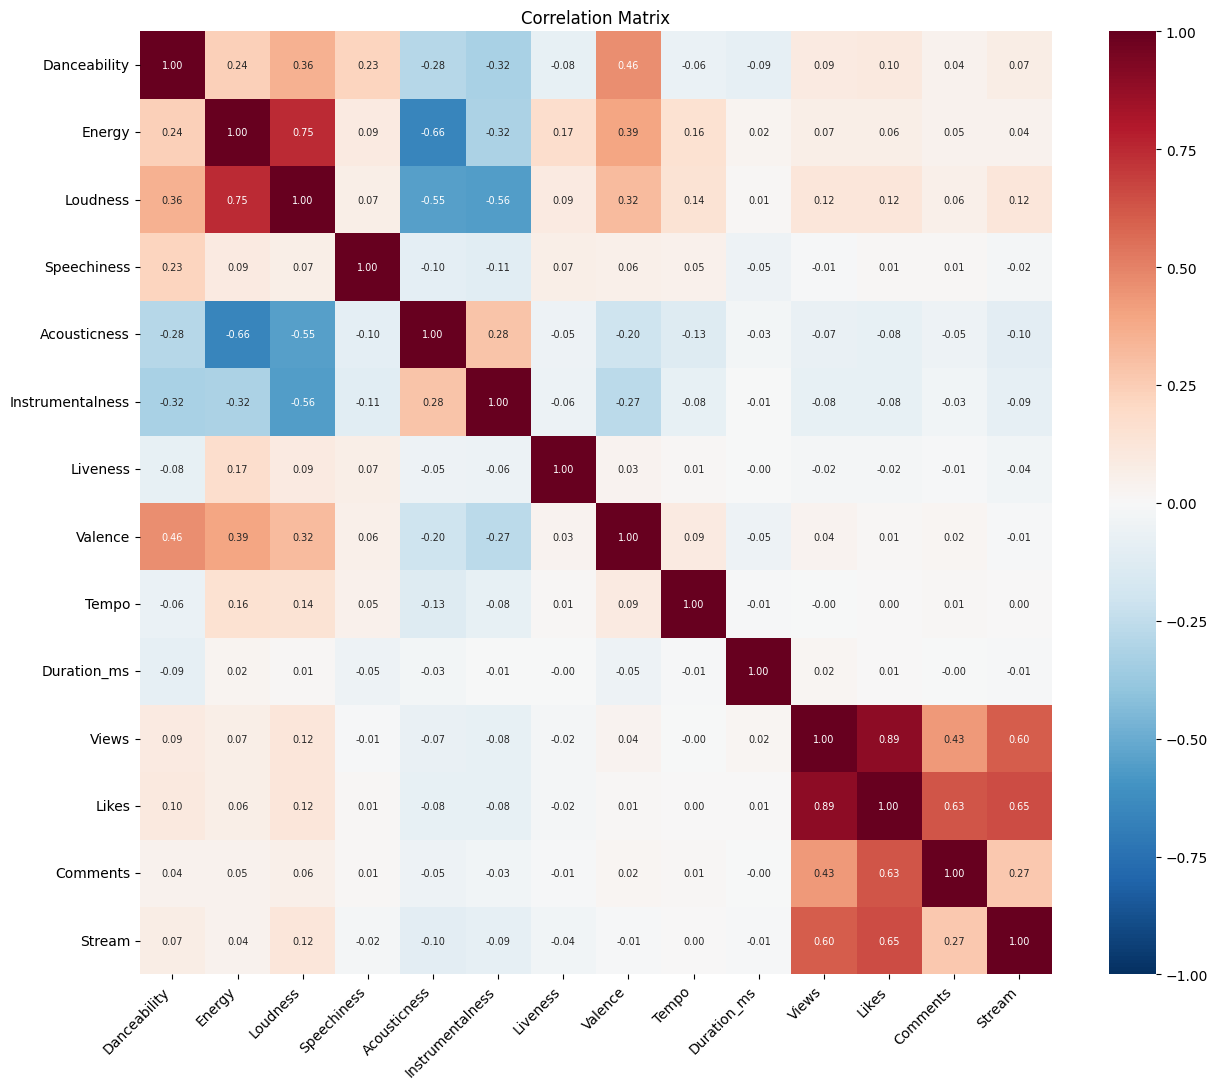

In [115]:
# Correlation heatmap
numeric_cols = spotify.select_dtypes(include=np.number).drop(
    columns=["Key"], errors="ignore"
)
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

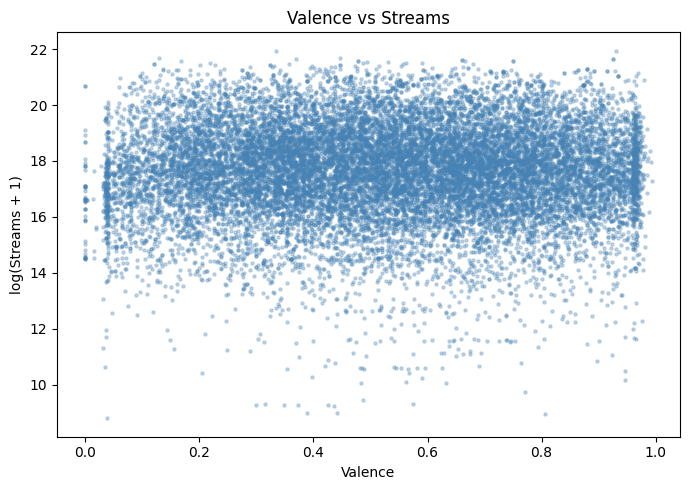

In [116]:
# Scatter: Streams vs Valence
plt.figure(figsize=(7, 5))
plt.scatter(spotify["Valence"], np.log1p(spotify["Stream"]),
            alpha=0.3, s=5, color="steelblue")
plt.title("Valence vs Streams")
plt.xlabel("Valence")
plt.ylabel("log(Streams + 1)")
plt.tight_layout()
plt.show()

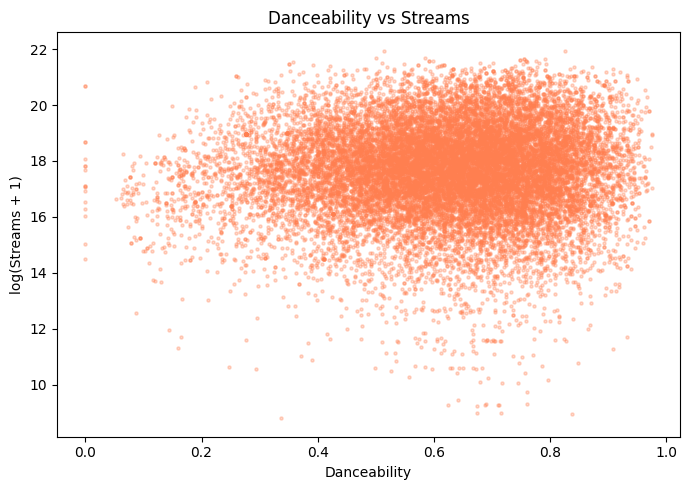

In [117]:
# Scatter: Danceability vs Streams
plt.figure(figsize=(7, 5))
plt.scatter(spotify["Danceability"], np.log1p(spotify["Stream"]),
            alpha=0.3, s=5, color="coral")
plt.title("Danceability vs Streams")
plt.xlabel("Danceability")
plt.ylabel("log(Streams + 1)")
plt.tight_layout()
plt.show()

## K-Means Clustering

In [118]:
# Standardize features
features_to_scale = [
    "Valence", "Acousticness", "Danceability", "Duration_ms", "Energy",
    "Instrumentalness", "Key", "Liveness", "Loudness", "Speechiness", "Tempo",
]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(spotify[features_to_scale])
print("Scaled data shape:", data_scaled.shape)

Scaled data shape: (19624, 11)


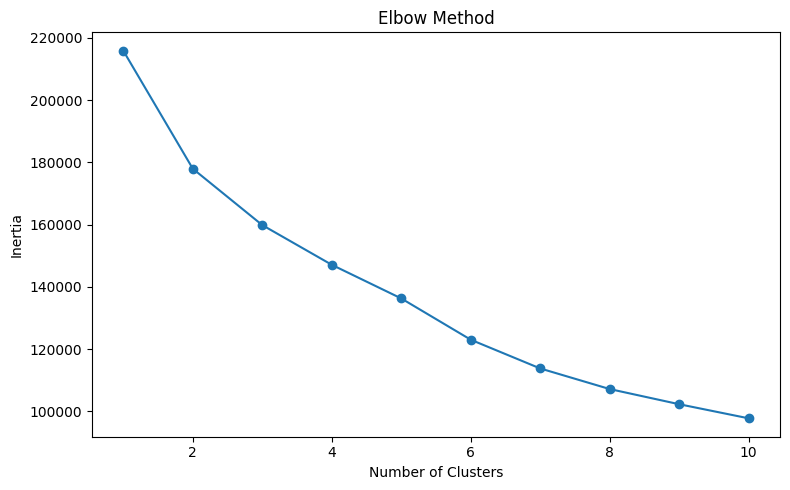

In [119]:
# Elbow method
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [120]:
# Fit KMeans with k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
spotify["cluster"] = kmeans.fit_predict(data_scaled) + 1  # 1-indexed
spotify["cluster"].value_counts().sort_index()

cluster
1    11288
2      803
3     2724
4     4809
Name: count, dtype: int64

In [121]:
spotify.head(5)

,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream,cluster
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,NaN,NaN,1.040235e+09,1
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,NaN,NaN,3.100837e+08,1
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,NaN,NaN,6.306347e+07,1
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,-5.810,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,NaN,NaN,4.346636e+08,1
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,-8.627,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,NaN,NaN,6.172597e+08,1


## PCA Visualization

In [122]:
# Reduce to 2 components
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "cluster": spotify["cluster"].values,
})
pca_df.head()

,PC1,PC2,cluster
0,1.828859,-0.141280,1
1,1.049768,0.845660,1
2,1.396952,-0.327591,1
3,0.024933,-0.343010,1
4,0.834829,-0.296222,1


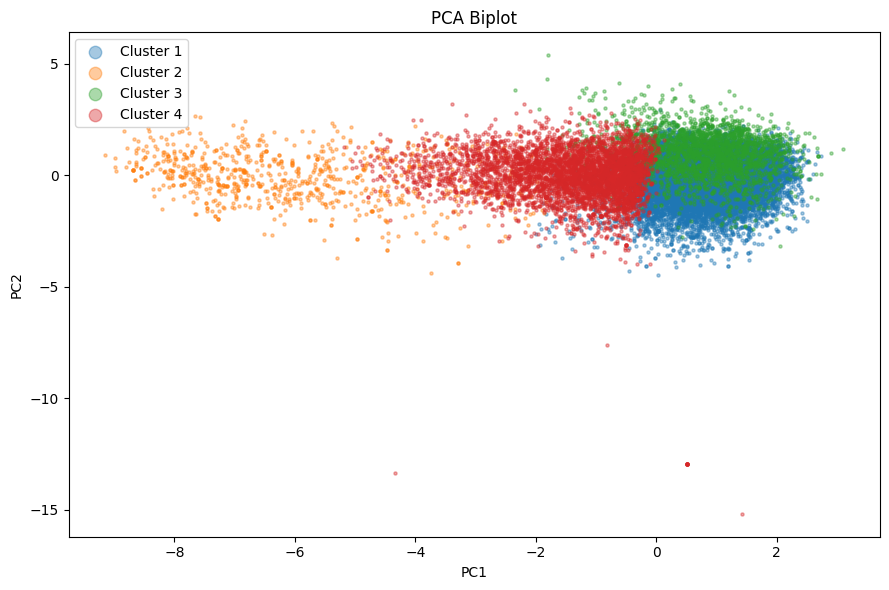

In [123]:
# PCA scatter coloured by cluster
fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id in sorted(pca_df["cluster"].unique()):
    mask = pca_df["cluster"] == cluster_id
    ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
               s=5, alpha=0.4, label=f"Cluster {cluster_id}")
ax.set_title("PCA Biplot")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## Cluster Analysis

In [124]:
# Mean valence and streams by cluster and album type
mean_data = (
    spotify.groupby(["cluster", "Album_type"])[["Valence", "Stream"]]
    .mean()
    .reset_index()
)
mean_data.sort_values("Stream", ascending=False)

,cluster,Album_type,Valence,Stream
0,1,album,0.615296,1.702752e+08
6,3,album,0.549075,1.477360e+08
9,4,album,0.392466,1.309604e+08
2,1,single,0.582285,1.070777e+08
11,4,single,0.364800,1.067499e+08
1,1,compilation,0.662068,9.789815e+07
8,3,single,0.560577,8.696879e+07
10,4,compilation,0.400588,8.343897e+07
7,3,compilation,0.627384,7.287701e+07
5,2,single,0.191441,6.188710e+07


In [125]:
# Cluster summary: mean valence, streams, and most common album type
cluster_means = spotify.groupby("cluster")[["Valence", "Stream"]].mean()
most_common_album = (
    spotify.groupby("cluster")["Album_type"]
    .agg(lambda x: x.value_counts().idxmax())
)
final_data = cluster_means.join(most_common_album).reset_index()
final_data.columns = ["cluster", "valence_mean", "stream_mean", "album_type"]
final_data.sort_values("stream_mean", ascending=False)

,cluster,valence_mean,stream_mean,album_type
0,1,0.608111,1.516584e+08,album
2,3,0.554408,1.286419e+08,album
3,4,0.387626,1.238736e+08,album
1,2,0.171921,4.135974e+07,album


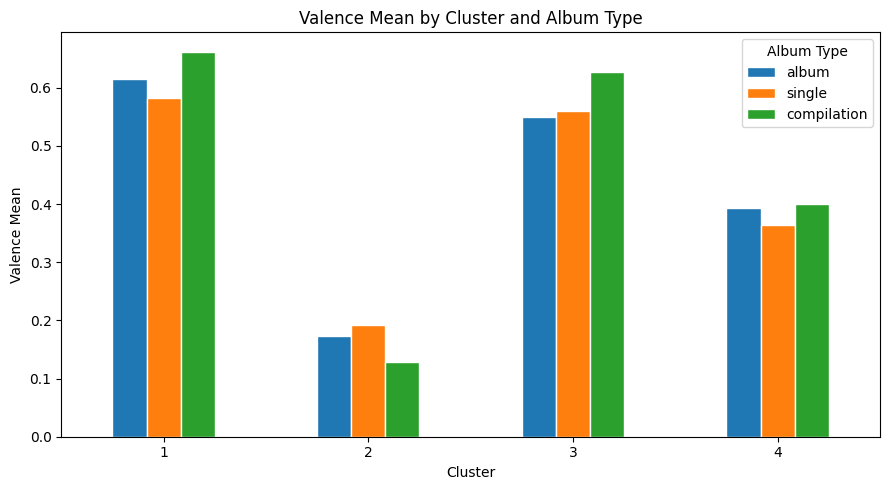

In [126]:
# Grouped bar: valence mean by cluster and album type
album_order = spotify["Album_type"].value_counts().index.tolist()
pivot = mean_data.pivot(index="cluster", columns="Album_type", values="Valence")
pivot = pivot[[c for c in album_order if c in pivot.columns]]

pivot.plot(kind="bar", figsize=(9, 5), edgecolor="white")
plt.title("Valence Mean by Cluster and Album Type")
plt.xlabel("Cluster")
plt.ylabel("Valence Mean")
plt.legend(title="Album Type", loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
reg_features = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo", "Duration_ms", "Key",
]

X = spotify[reg_features]
y = np.log1p(spotify["Stream"])  # log-transform to reduce skew

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (15699, 11) Test: (3925, 11)


In [128]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

=== Linear Regression ===
R²:   0.0725
RMSE: 1.5947


In [129]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("=== Random Forest Regressor ===")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

=== Random Forest Regressor ===
R²:   0.2193
RMSE: 1.4630


In [130]:
# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

print("=== Gradient Boosting Regressor ===")
print(f"R²:   {r2_score(y_test, y_pred_gb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}")

=== Gradient Boosting Regressor ===
R²:   0.1354
RMSE: 1.5396


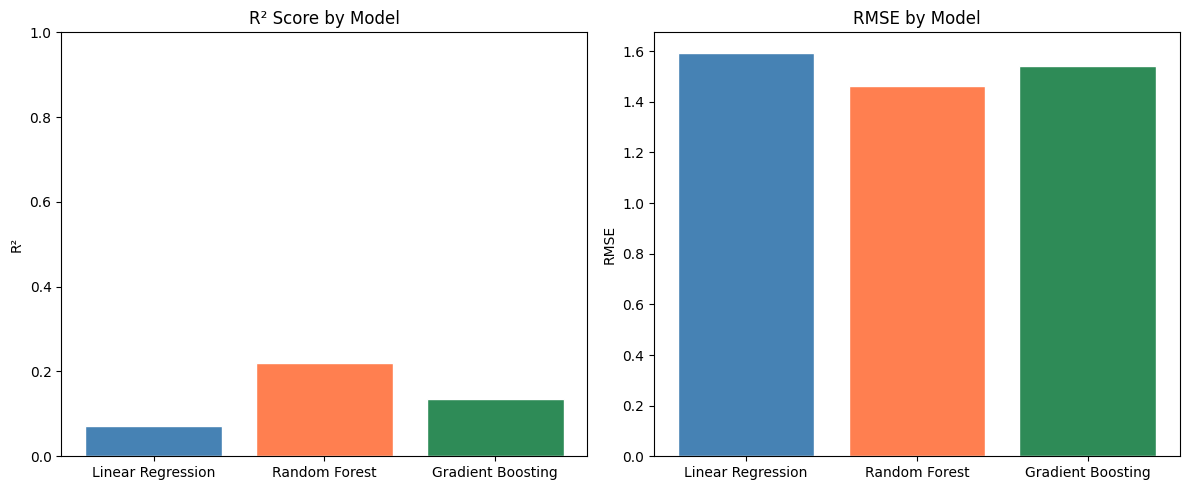

In [131]:
# Model comparison bar chart
models = ["Linear Regression", "Random Forest", "Gradient Boosting"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb),
]
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_gb)),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(models, r2_scores, color=["steelblue", "coral", "seagreen"], edgecolor="white")
axes[0].set_title("R² Score by Model")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)

axes[1].bar(models, rmse_scores, color=["steelblue", "coral", "seagreen"], edgecolor="white")
axes[1].set_title("RMSE by Model")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

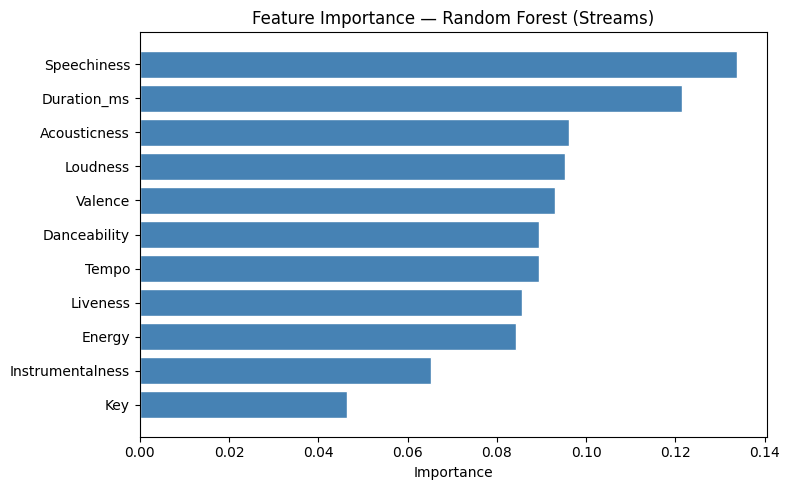

In [132]:
# Feature importance — Random Forest Regressor
importances = pd.Series(rf_reg.feature_importances_, index=reg_features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color="steelblue", edgecolor="white")
plt.title("Feature Importance — Random Forest (Streams)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

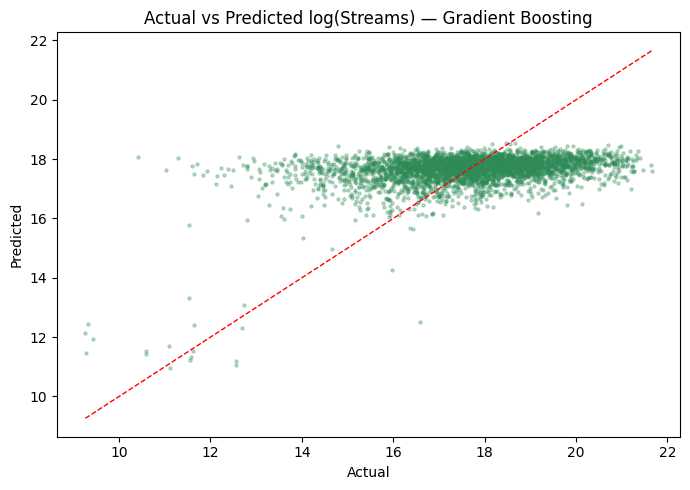

In [133]:
# Actual vs Predicted — best model (Gradient Boosting)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_gb, alpha=0.3, s=5, color="seagreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=1, linestyle="--")
plt.title("Actual vs Predicted log(Streams) — Gradient Boosting")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

## ML Model 3: Classification — Hit Song Prediction

In [134]:
# Define "hit" as top 25% of streams
threshold = spotify["Stream"].quantile(0.75)
spotify["hit"] = (spotify["Stream"] >= threshold).astype(int)

print(f"Stream threshold (75th percentile): {threshold:,.0f}")
print(f"Hit songs:     {spotify['hit'].sum():,}  ({spotify['hit'].mean()*100:.1f}%)")
print(f"Non-hit songs: {(spotify['hit'] == 0).sum():,}  ({(1 - spotify['hit'].mean())*100:.1f}%)")

Stream threshold (75th percentile): 139,207,371
Hit songs:     4,906  (25.0%)
Non-hit songs: 14,718  (75.0%)


In [135]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

X_hit = spotify[reg_features]
y_hit = spotify["hit"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hit, y_hit, test_size=0.2, random_state=42, stratify=y_hit
)
print("Train:", X_train_h.shape, "Test:", X_test_h.shape)

Train: (15699, 11) Test: (3925, 11)


In [136]:
# Decision Tree (depth-limited for interpretability)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_h, y_train_h)
y_pred_dt = dt.predict(X_test_h)

print("=== Decision Tree ===")
print(classification_report(y_test_h, y_pred_dt, target_names=["Non-Hit", "Hit"]))

=== Decision Tree ===
              precision    recall  f1-score   support

     Non-Hit       0.75      1.00      0.86      2944
         Hit       0.00      0.00      0.00       981

    accuracy                           0.75      3925
   macro avg       0.38      0.50      0.43      3925
weighted avg       0.56      0.75      0.64      3925



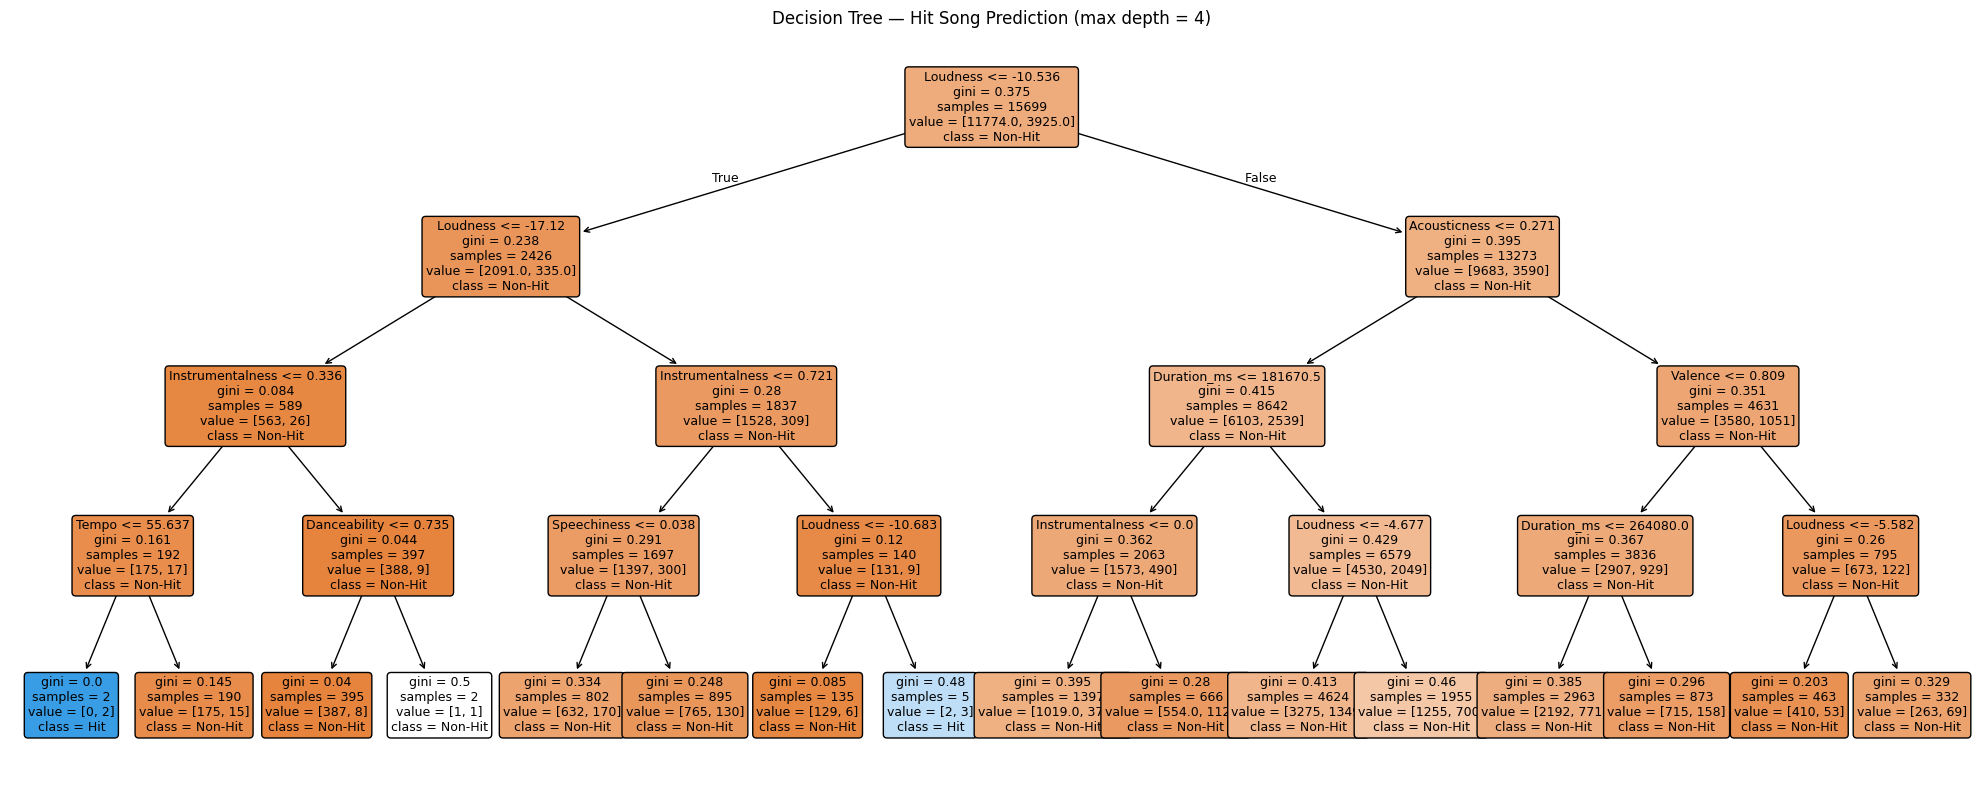

In [137]:
# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=reg_features, class_names=["Non-Hit", "Hit"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("Decision Tree — Hit Song Prediction (max depth = 4)")
plt.tight_layout()
plt.show()

In [138]:
# Random Forest Classifier
rf_hit = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_hit.fit(X_train_h, y_train_h)
y_pred_rf_hit = rf_hit.predict(X_test_h)

print("=== Random Forest ===")
print(classification_report(y_test_h, y_pred_rf_hit, target_names=["Non-Hit", "Hit"]))

=== Random Forest ===
              precision    recall  f1-score   support

     Non-Hit       0.79      0.99      0.88      2944
         Hit       0.86      0.19      0.31       981

    accuracy                           0.79      3925
   macro avg       0.82      0.59      0.59      3925
weighted avg       0.80      0.79      0.73      3925



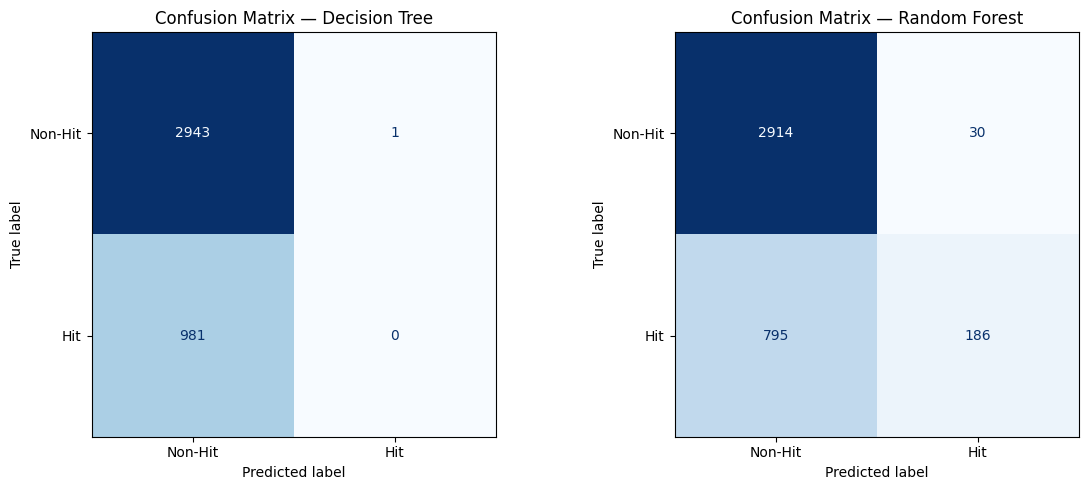

In [139]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
                             [y_pred_dt, y_pred_rf_hit],
                             ["Decision Tree", "Random Forest"]):
    cm = confusion_matrix(y_test_h, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Non-Hit", "Hit"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"Confusion Matrix — {title}")

plt.tight_layout()
plt.show()

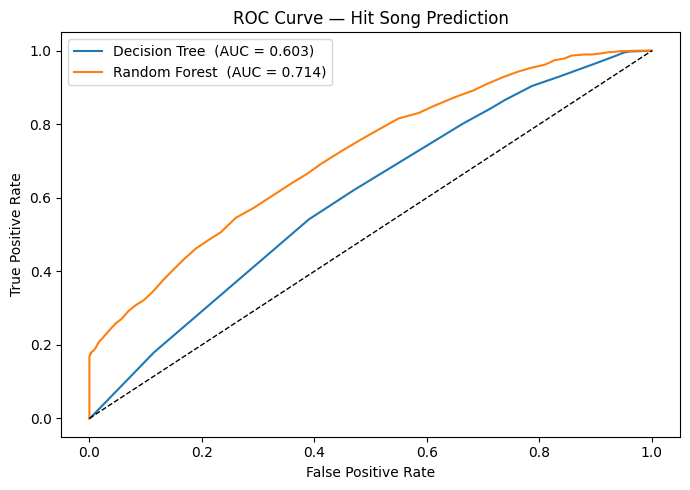

In [140]:
# ROC curves for both models
from sklearn.metrics import roc_curve, roc_auc_score

dt_probs  = dt.predict_proba(X_test_h)[:, 1]
rf_probs  = rf_hit.predict_proba(X_test_h)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test_h, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test_h, rf_probs)

auc_dt = roc_auc_score(y_test_h, dt_probs)
auc_rf = roc_auc_score(y_test_h, rf_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree  (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest  (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curve — Hit Song Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

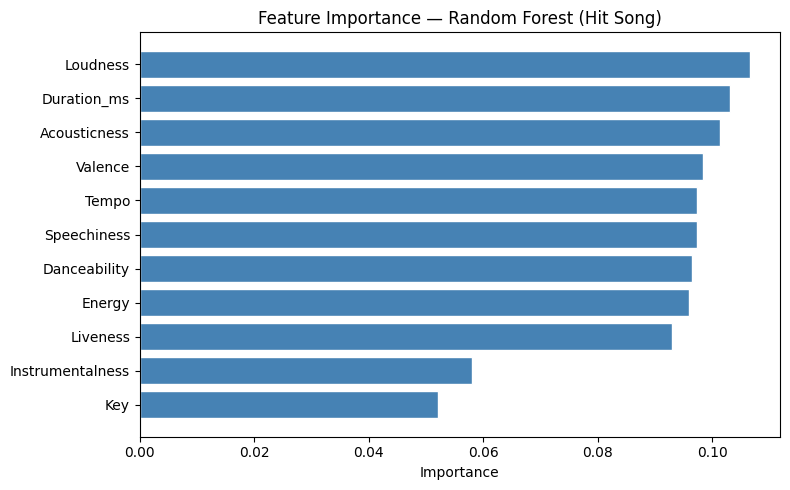

In [141]:
# Feature importance — which audio features best predict a hit?
hit_importances = pd.Series(rf_hit.feature_importances_, index=reg_features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(hit_importances.index, hit_importances.values, color="steelblue", edgecolor="white")
plt.title("Feature Importance — Random Forest (Hit Song)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()